# Computer Vision Problem Formulation and CNN Prototype
The project demonstrates:
- Image preprocessing
- CNN model creation
- Convolution and pooling operations
- Model training and evaluation
- Prediction visualization

In [1]:
# Importing required libraries

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

# Task 1: Problem Identification
This dataset represents an **Image Classification** problem.

Reason:
- Each image belongs to one specific category.
- The goal is to classify the product image into one of four defect classes:
    - normal
    - scratch
    - dent
    - stain

The dataset does not require object localization or pixel-level segmentation, therefore image classification is the most appropriate computer vision problem type.

# Task 2: Dataset Exploration

In [2]:
# Dataset path

dataset_path = "images"

classes = os.listdir(dataset_path)

print("Classes:", classes)

Classes: ['dent', 'normal', 'scratch', 'stain']


In [3]:
# Counting images in each class

image_count = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_count[class_name] = len(os.listdir(class_path))

image_count

{'dent': 120, 'normal': 120, 'scratch': 120, 'stain': 120}

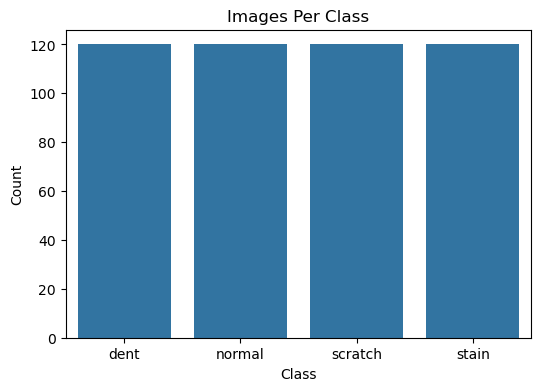

In [4]:
# Visualizing class distribution

plt.figure(figsize=(6,4))

sns.barplot(
    x=list(image_count.keys()),
    y=list(image_count.values())
)

plt.title("Images Per Class")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

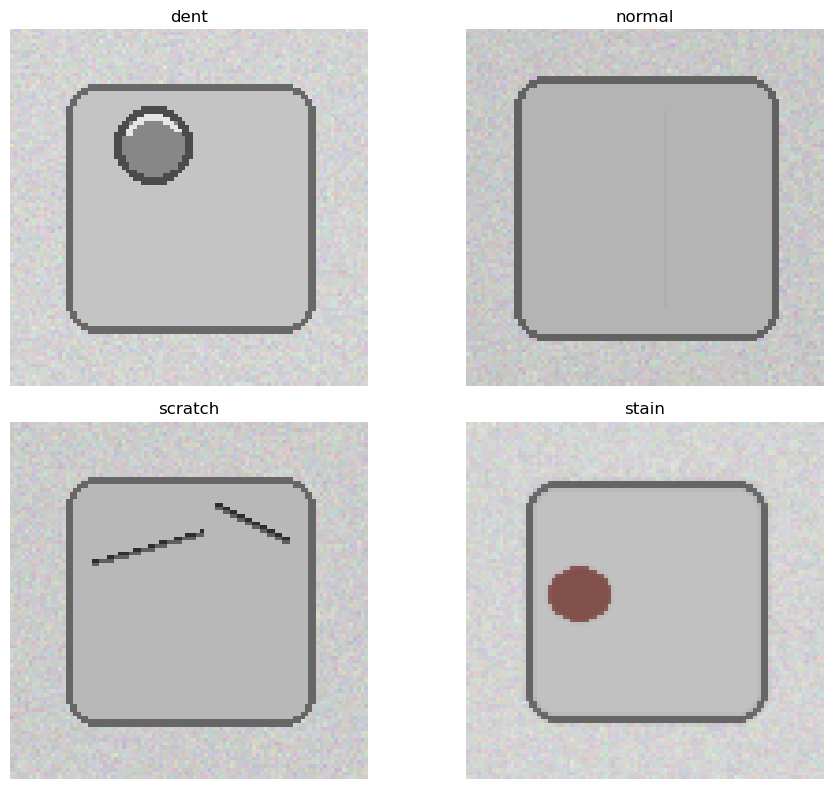

In [5]:
# Displaying sample images

plt.figure(figsize=(10,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [6]:
# Checking image dimensions

sample_image = Image.open(image_path)

print("Image Size:", sample_image.size)

Image Size: (96, 96)


# Task 3: Image Preprocessing

In [7]:
# Loading and preprocessing images

image_size = 128

X = []
y = []

for class_index, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        image = image.resize((image_size, image_size))

        image = np.array(image)

        # Normalize pixel values
        image = image / 255.0

        X.append(image)

        y.append(class_index)

X = np.array(X)
y = np.array(y)

print("Image Data Shape:", X.shape)
print("Label Shape:", y.shape)

Image Data Shape: (480, 128, 128, 3)
Label Shape: (480,)


In [8]:
# Splitting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (384, 128, 128, 3)
Testing Data: (96, 128, 128, 3)


In [9]:
# One-hot encoding labels

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Task 4: CNN Model Creation

In [10]:
# Building CNN model

model = Sequential()

# First convolution block
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution block
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Third convolution block
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Dropout for regularization
model.add(Dropout(0.3))

# Output layer
model.add(Dense(4, activation='softmax'))

c:\Users\jbred\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compiling CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training and Evaluation

In [13]:
# Training CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 730ms/step - accuracy: 0.2689 - loss: 1.4918 - val_accuracy: 0.2338 - val_loss: 1.3876
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 477ms/step - accuracy: 0.3401 - loss: 1.3715 - val_accuracy: 0.3117 - val_loss: 1.3511
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 495ms/step - accuracy: 0.4622 - loss: 1.2788 - val_accuracy: 0.4805 - val_loss: 1.0914
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 844ms/step - accuracy: 0.5376 - loss: 1.0174 - val_accuracy: 0.5844 - val_loss: 0.9112
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6525 - loss: 0.7683 - val_accuracy: 0.5325 - val_loss: 0.9152
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 792ms/step - accuracy: 0.7162 - loss: 0.7256 - val_accuracy: 0.7013 - val_loss: 0.6993
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 721ms/step - accuracy: 0.7877 - loss: 0.4643 - val_accuracy: 0.8052 - val_loss: 0.4507
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8854 - loss: 0.3447 - val_accuracy: 0.779

## Accuracy Curves

The following graph shows training and validation accuracy during training.

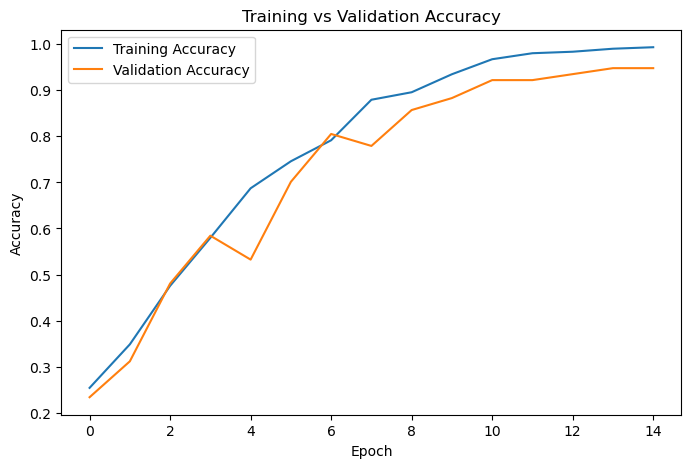

In [14]:
# Plotting accuracy curves

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

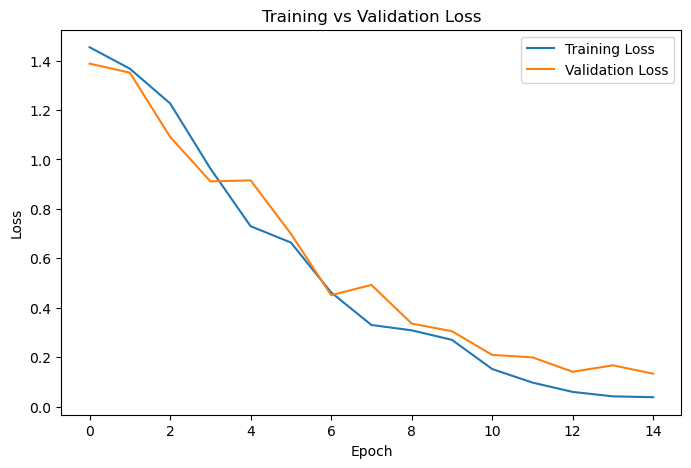

In [15]:
# Plotting loss curves

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [16]:
# Evaluating model

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step - accuracy: 0.9401 - loss: 0.1739
Test Loss: 0.1363825798034668
Test Accuracy: 0.9583333134651184


In [17]:
# Predicting test images

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step


## Confusion Matrix

The confusion matrix helps visualize classification performance for each defect category.

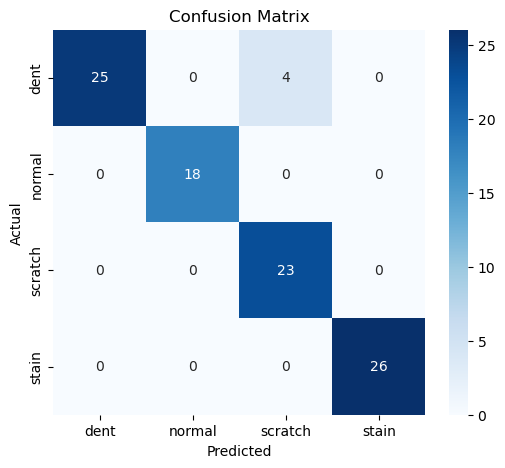

In [18]:
# Creating confusion matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [19]:
# Classification report

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=classes
    )
)

              precision    recall  f1-score   support

        dent       1.00      0.86      0.93        29
      normal       1.00      1.00      1.00        18
     scratch       0.85      1.00      0.92        23
       stain       1.00      1.00      1.00        26

    accuracy                           0.96        96
   macro avg       0.96      0.97      0.96        96
weighted avg       0.96      0.96      0.96        96



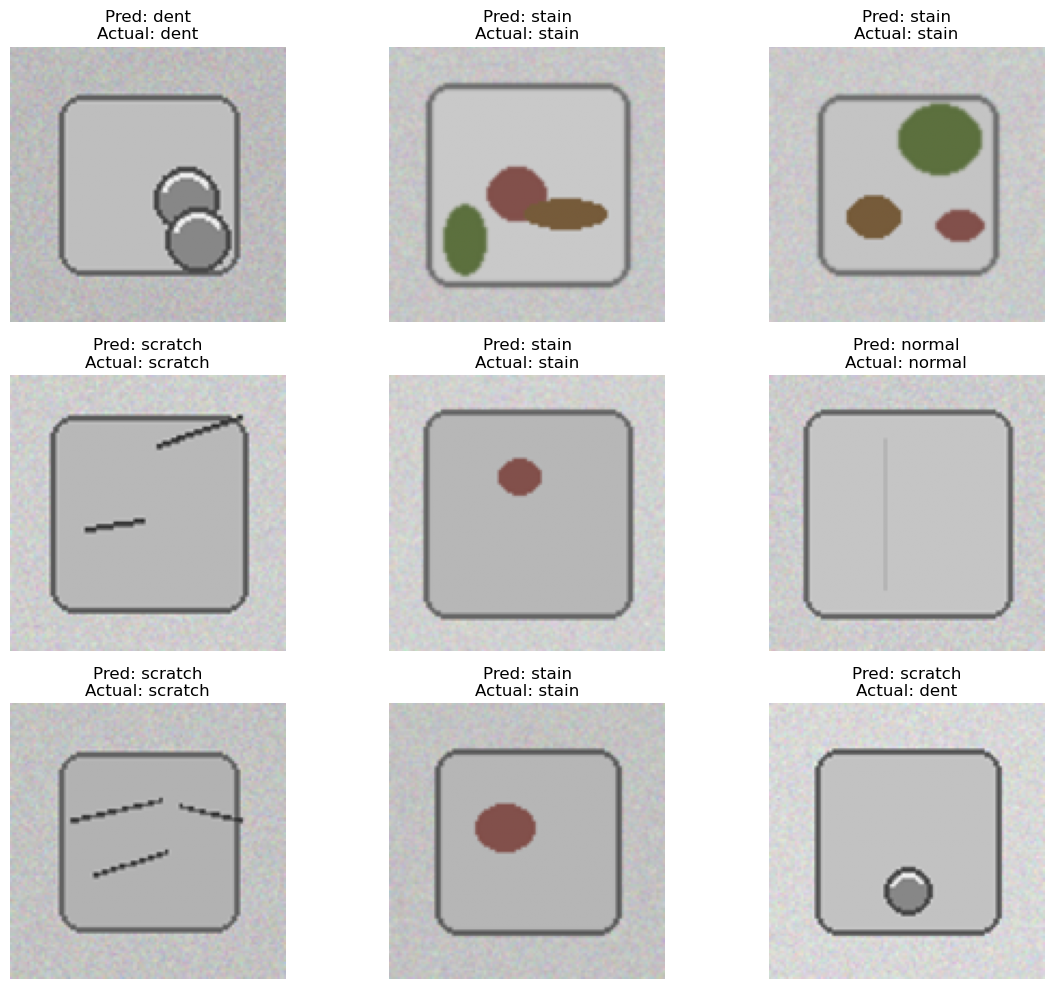

In [20]:
# Displaying sample predictions

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    predicted_label = classes[predicted_classes[i]]

    true_label = classes[true_classes[i]]

    plt.title(f"Pred: {predicted_label}\nActual: {true_label}")

    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

# Task 7: Business Use Case Mapping



This type of computer vision solution can be used in the manufacturing industry for automated quality inspection.

Example use cases:
- Detecting scratches or dents on products
- Identifying damaged surfaces during production
- Reducing manual inspection effort
- Improving product quality control
- Increasing manufacturing efficiency

CNN-based inspection systems help industries identify defective products faster and more accurately.